# 02 — Statistical Analysis & Hypothesis Testing

Notebook này đi sâu vào 3 câu hỏi thống kê quan trọng nhất từ EDA (`01_eda.ipynb`), thay vì
chạy dàn trải nhiều test. Mỗi câu hỏi theo đúng format khoa học đầy đủ:

```
Business Question -> H0/H1 -> Vì sao chọn test này -> Visualization
-> Assumption Check -> Statistical Test -> Giải thích p-value
-> Effect Size -> Business Implication
```

**Nguyên tắc quan trọng xuyên suốt:** p-value chỉ trả lời "có khác biệt hay không", KHÔNG trả lời
"khác biệt đó có đáng để hành động không" — đó là việc của effect size.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import text

from src.database import get_engine

sns.set_style('whitegrid')
engine = get_engine()
ALPHA = 0.05  # muc y nghia dung xuyen suot notebook

2026-08-04 14:57:47 | INFO     | src.database | Created SQLAlchemy engine for PostgreSQL.


### Cách đọc p-value trong notebook này (đọc trước khi xem kết quả)

- **p-value KHÔNG phải** "xác suất H0 đúng".
- **p-value LÀ** xác suất quan sát được dữ liệu cực đoan như thế này (hoặc hơn), **nếu giả sử H0 đúng**.
- p-value < 0.05 → đủ bằng chứng để bác bỏ H0, kết luận có khác biệt/tương quan có ý nghĩa thống kê.
- Với dataset lớn (~90,000 dòng), p-value gần như luôn < 0.05 kể cả khi hiệu ứng thực tế rất nhỏ
  — đây là lý do notebook này LUÔN báo cáo kèm **effect size**, không dừng lại ở p-value.

---
# Câu hỏi 1: Đơn hàng giá trị cao có được review tốt hơn không?

**Business Question:** giá trị đơn hàng có ảnh hưởng đến điểm review không? Nếu có, có thể dùng
để dự đoán rủi ro review thấp cho đơn giá trị thấp, từ đó ưu tiên chăm sóc khách hàng phù hợp.

**Hypothesis:**
- H0: review_score trung bình bằng nhau giữa các nhóm order value bucket
- H1: có ít nhất 1 nhóm order value có review_score trung bình khác biệt

**Vì sao chọn ANOVA/Kruskal-Wallis (không phải t-test):** có 4 nhóm order value (<50, 50-150,
150-300, 300+), t-test chỉ so sánh được 2 nhóm — cần test so sánh được nhiều nhóm cùng lúc.

In [2]:
q1 = """
SELECT
    CASE
        WHEN p.total_payment_value < 50 THEN '<50'
        WHEN p.total_payment_value < 150 THEN '50-150'
        WHEN p.total_payment_value < 300 THEN '150-300'
        ELSE '300+'
    END AS bucket,
    r.review_score
FROM orders_clean o
JOIN payments_per_order p ON p.order_id = o.order_id
JOIN order_reviews r ON r.order_id = o.order_id;
"""

df1 = pd.read_sql(text(q1), engine)
df1.head()

,bucket,review_score
0,50-150,5
1,150-300,4
2,150-300,5
3,<50,4
4,150-300,5


**Visualization**

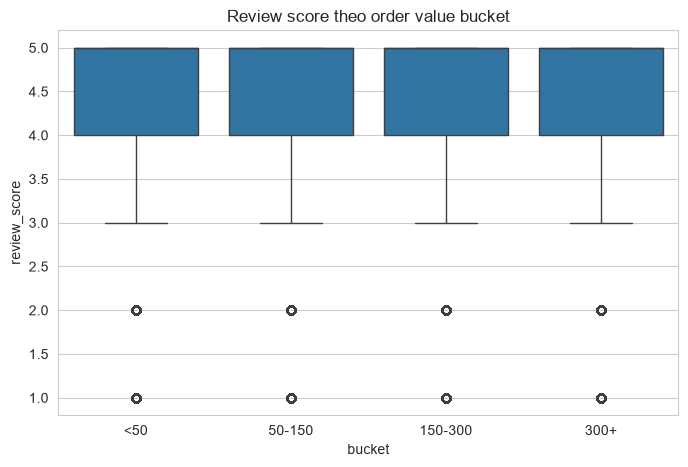

,mean,median,count
bucket,,,
<50,4.250167,5.0,16481
50-150,4.180823,5.0,48705
150-300,4.086759,5.0,21312
300+,4.023220,5.0,9862


In [3]:
order = ['<50', '50-150', '150-300', '300+']
plt.figure(figsize=(8, 5))
sns.boxplot(data=df1, x='bucket', y='review_score', order=order)
plt.title('Review score theo order value bucket')
plt.show()

df1.groupby('bucket')['review_score'].agg(['mean', 'median', 'count']).reindex(order)

**Assumption Check:** ANOVA giả định (1) phân phối chuẩn trong từng nhóm, (2) phương sai đồng
nhất giữa các nhóm (homogeneity of variance). `review_score` là thang đo rời rạc 1-5 — gần như
chắc chắn vi phạm giả định phân phối chuẩn. Kiểm tra bằng Shapiro-Wilk trên mẫu con (Shapiro giới
hạn n≤5000).

In [4]:
for b in order:
    sample = df1[df1['bucket'] == b]['review_score'].sample(min(500, len(df1[df1['bucket'] == b])), random_state=42)
    stat, p = stats.shapiro(sample)
    verdict = 'KHONG chuan (p<0.05)' if p < 0.05 else 'co the xem la chuan'
    print(f'{b:10s} Shapiro p-value: {p:.4f} -> {verdict}')

<50        Shapiro p-value: 0.0000 -> KHONG chuan (p<0.05)
50-150     Shapiro p-value: 0.0000 -> KHONG chuan (p<0.05)
150-300    Shapiro p-value: 0.0000 -> KHONG chuan (p<0.05)
300+       Shapiro p-value: 0.0000 -> KHONG chuan (p<0.05)


**Kết luận assumption check:** như dự đoán, `review_score` vi phạm giả định normality (thang đo
rời rạc 1-5 điểm). Vì vậy notebook chạy **cả ANOVA (tham chiếu, ai quen thuộc test này cũng đọc
được) lẫn Kruskal-Wallis (phi tham số, đáng tin cậy hơn khi vi phạm normality)** — nếu 2 kết quả
đồng thuận, kết luận càng vững chắc.

**Statistical Test**

In [5]:
groups1 = [g['review_score'].values for _, g in df1.groupby('bucket')]

f_stat, p_anova = stats.f_oneway(*groups1)
h_stat, p_kruskal = stats.kruskal(*groups1)

print(f'ANOVA:          F={f_stat:.4f}, p={p_anova:.6f}')
print(f'Kruskal-Wallis: H={h_stat:.4f}, p={p_kruskal:.6f}')
print()
print('Bac bo H0 (p<0.05)' if p_kruskal < ALPHA else 'Khong du bang chung bac bo H0')

ANOVA:          F=91.5496, p=0.000000
Kruskal-Wallis: H=138.1686, p=0.000000

Bac bo H0 (p<0.05)


**Giải thích p-value cho kết quả trên:** nếu p < 0.05, điều này có nghĩa: *giả sử review_score
thực sự KHÔNG khác nhau giữa các nhóm order value (H0 đúng), xác suất quan sát được sự khác biệt
lớn như trong mẫu dữ liệu này (hoặc lớn hơn) là rất nhỏ (<5%)* — vì vậy ta có đủ bằng chứng để
bác bỏ H0 và kết luận có khác biệt thật.

**Effect Size — Eta-squared (η²) cho ANOVA**

| η² | Mức độ (Cohen, 1988) |
|---|---|
| < 0.01 | Không đáng kể |
| 0.01 - 0.06 | Nhỏ |
| 0.06 - 0.14 | Trung bình |
| > 0.14 | Lớn |

In [6]:
# Eta-squared = SS_between / SS_total
grand_mean = df1['review_score'].mean()
ss_total = ((df1['review_score'] - grand_mean) ** 2).sum()
ss_between = sum(
    len(g) * (g.mean() - grand_mean) ** 2
    for _, g in df1.groupby('bucket')['review_score']
)
eta_squared = ss_between / ss_total

effect_label = (
    'khong dang ke' if eta_squared < 0.01 else
    'nho' if eta_squared < 0.06 else
    'trung binh' if eta_squared < 0.14 else
    'lon'
)
print(f'Eta-squared = {eta_squared:.4f} -> muc do anh huong: {effect_label}')

Eta-squared = 0.0028 -> muc do anh huong: khong dang ke


**Business Implication**
*(điền sau khi chạy với data thật)*

- Nếu p<0.05 nhưng η² nhỏ ("khong dang ke"/"nho"): kết luận đúng là có khác biệt thống kê,
  nhưng **không nên xây chiến lược lớn chỉ dựa trên order value để dự đoán review** — cần tìm
  yếu tố khác có effect size lớn hơn (VD: delivery time, category sản phẩm).
- Nếu η² ở mức trung bình/lớn: đáng để đầu tư — VD: chăm sóc khách hàng ưu tiên hơn cho nhóm
  order value cao (vì rủi ro/lợi ích của review từ nhóm này lớn hơn).

---
# Câu hỏi 2: Payment type có ảnh hưởng đến giá trị đơn hàng không?

**Business Question:** phương thức thanh toán có liên quan gì đến độ lớn đơn hàng? Nếu có, có thể
cân nhắc khuyến khích phương thức thanh toán gắn với đơn giá trị cao hơn.

**Hypothesis:**
- H0: order value trung bình bằng nhau giữa các payment type
- H1: có ít nhất 1 payment type có order value trung bình khác biệt

**Vì sao chọn test này:** tương tự câu hỏi 1 — nhiều nhóm (>2 payment type), biến liên tục
(order value) nhưng lệch phải mạnh → dùng cả ANOVA và Kruskal-Wallis.

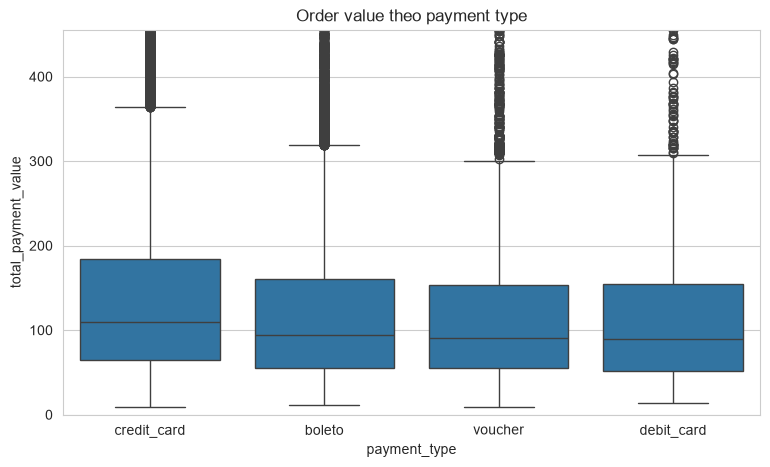

,mean,median,count
payment_type,,,
boleto,145.034435,93.89,19784
credit_card,167.174987,109.22,76795
debit_card,142.667632,89.30,1529
voucher,141.309733,90.12,5775


In [7]:
q2 = """
SELECT op.payment_type, p.total_payment_value
FROM order_payments op
JOIN payments_per_order p ON p.order_id = op.order_id
WHERE op.payment_type != 'not_defined';
"""

df2 = pd.read_sql(text(q2), engine)

plt.figure(figsize=(9, 5))
sns.boxplot(data=df2, x='payment_type', y='total_payment_value')
plt.ylim(0, df2['total_payment_value'].quantile(0.95))
plt.title('Order value theo payment type')
plt.show()

df2.groupby('payment_type')['total_payment_value'].agg(['mean', 'median', 'count'])

In [8]:
groups2 = [g['total_payment_value'].values for _, g in df2.groupby('payment_type') if len(g) > 30]

f_stat2, p_anova2 = stats.f_oneway(*groups2)
h_stat2, p_kruskal2 = stats.kruskal(*groups2)

print(f'ANOVA:          F={f_stat2:.4f}, p={p_anova2:.6f}')
print(f'Kruskal-Wallis: H={h_stat2:.4f}, p={p_kruskal2:.6f}')

ANOVA:          F=72.4118, p=0.000000
Kruskal-Wallis: H=747.0631, p=0.000000


In [9]:
grand_mean2 = df2['total_payment_value'].mean()
ss_total2 = ((df2['total_payment_value'] - grand_mean2) ** 2).sum()
ss_between2 = sum(
    len(g) * (g.mean() - grand_mean2) ** 2
    for _, g in df2.groupby('payment_type')['total_payment_value']
)
eta_squared2 = ss_between2 / ss_total2
print(f'Eta-squared = {eta_squared2:.4f}')

Eta-squared = 0.0021


**Giải thích p-value & Business Implication**
*(điền sau khi chạy với data thật)* — nếu payment type khác nhau có order value khác biệt CÓ Ý
NGHĨA (p<0.05) VÀ effect size không nhỏ, cân nhắc: hiển thị ưu đãi/khuyến mãi rõ hơn cho phương
thức thanh toán liên quan tới đơn giá trị cao, để khuyến khích khách chọn phương thức đó.

---
# Câu hỏi 3: Delivery time có tương quan với review score không?

**Business Question:** giao hàng chậm có thực sự làm giảm review score không? Đây là câu hỏi
quan trọng để quyết định có đáng đầu tư cải thiện logistics hay không.

**Hypothesis:**
- H0: không có tương quan giữa delivery_days và review_score (rho = 0)
- H1: có tương quan (rho ≠ 0)

**Vì sao chọn Spearman (không phải Pearson):** `review_score` là biến thứ tự (ordinal 1-5),
không phải liên tục — Pearson giả định quan hệ tuyến tính giữa 2 biến liên tục, không phù hợp
ở đây. Spearman đo tương quan **thứ hạng** (monotonic), phù hợp hơn với dữ liệu ordinal.

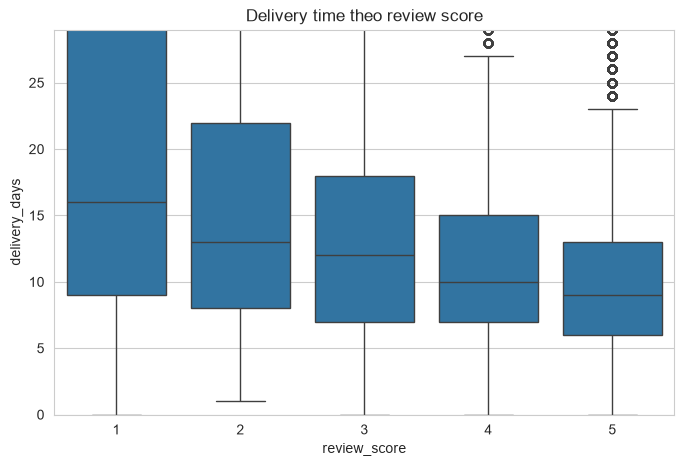

In [10]:
q3 = """
SELECT
    EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp)) AS delivery_days,
    r.review_score
FROM orders o
JOIN order_reviews r ON r.order_id = o.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL;
"""

df3 = pd.read_sql(text(q3), engine).dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df3, x='review_score', y='delivery_days')
plt.ylim(0, df3['delivery_days'].quantile(0.95))
plt.title('Delivery time theo review score')
plt.show()

In [11]:
rho, p_spearman = stats.spearmanr(df3['delivery_days'], df3['review_score'])
print(f'Spearman rho = {rho:.4f}, p-value = {p_spearman:.6f}')
print('Bac bo H0 (p<0.05)' if p_spearman < ALPHA else 'Khong du bang chung bac bo H0')

Spearman rho = -0.2344, p-value = 0.000000
Bac bo H0 (p<0.05)


**Giải thích p-value:** với n lớn (~90,000 dòng), p-value gần như chắc chắn < 0.05 ngay cả khi
rho rất nhỏ — **đây là lý do effect size (|rho|) quan trọng hơn p-value ở bước tiếp theo.**

**Effect Size**

| |rho| | Mức độ |
|---|---|
| < 0.1 | Không đáng kể |
| 0.1 - 0.3 | Yếu |
| 0.3 - 0.5 | Trung bình |
| > 0.5 | Mạnh |

In [12]:
effect_label3 = (
    'khong dang ke' if abs(rho) < 0.1 else
    'yeu' if abs(rho) < 0.3 else
    'trung binh' if abs(rho) < 0.5 else
    'manh'
)
print(f'|rho| = {abs(rho):.4f} -> muc do anh huong: {effect_label3}')

|rho| = 0.2344 -> muc do anh huong: yeu


**Business Implication**
*(điền sau khi chạy với data thật)*

- Nếu rho âm và effect size từ trung bình trở lên: giao hàng chậm THỰC SỰ làm giảm review score
  đáng kể → đầu tư cải thiện logistics là ưu tiên cao, có thể ảnh hưởng trực tiếp đến uy tín seller.
- Nếu effect size chỉ ở mức yếu: delivery time có ảnh hưởng nhưng KHÔNG PHẢI yếu tố quyết định
  duy nhất — review score còn bị chi phối bởi chất lượng sản phẩm, kỳ vọng cá nhân, và các yếu tố
  khác chưa đo được trong dataset này. Tránh kết luận "chỉ cần giao nhanh là đủ" nếu effect size yếu.

---
# Tổng kết Statistical Analysis
*(điền số liệu thật sau khi chạy)*

| Câu hỏi | Test | p-value | Effect Size | Kết luận business |
|---|---|---|---|---|
| Order value vs Review score | ANOVA/Kruskal-Wallis | ___ | η²=___ | ___ |
| Payment type vs Order value | ANOVA/Kruskal-Wallis | ___ | η²=___ | ___ |
| Delivery time vs Review score | Spearman | ___ | rho=___ | ___ |

**Lưu ý khi trình bày phỏng vấn:** luôn báo cáo effect size cùng p-value, không dừng ở p-value
một mình — đây là điểm khác biệt giữa 1 phân tích thống kê hời hợt và 1 phân tích thống kê chắc chắn.